# Orthomosaic tiling for ML (RGB)

This notebook:
1. Selects a pseudo orthomosaic jpg
2. Computes coverage area and saves/displays a quicklook PNG
3. Tiles the valid (non-black / non-nodata) region into fixed-size tiles with overlap
4. Skips mostly-empty tiles and writes per-tile JSON metadata


In [1]:
# 0 — Imports

from pathlib import Path
import json
import random
import shutil

import numpy as np

# For JPG/PNG reading
from PIL import Image

# Optional (for display)
try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

In [2]:
from PIL import Image

# Allow very large images (drone mosaics can exceed PIL's safety threshold)
Image.MAX_IMAGE_PIXELS = None   # or set to an int like 500_000_000

In [3]:
# 1 — Select case folder and pseudo-ortho image

from pathlib import Path

PSEUDO_ROOT = Path("./output/pseudo_ortho")   # contains case folders
OUT_ROOT    = Path("./output/tiles_out_pseudo_ortho")


def pick_case(root: Path) -> Path:
    cases = sorted([p for p in root.iterdir() if p.is_dir() and not p.name.startswith('.')])

    if not cases:
        raise FileNotFoundError(f"No case folders found in {root.resolve()}")

    print("\nAvailable cases:")
    for i, c in enumerate(cases, 1):
        print(f"{i:2d}) {c.name}")

    choice = int(input("\nSelect a case number: ").strip())
    if choice < 1 or choice > len(cases):
        raise ValueError("Invalid selection.")

    return cases[choice - 1]


def pick_image(folder: Path) -> Path:
    imgs = (
        sorted(folder.glob("*.jpg")) +
        sorted(folder.glob("*.jpeg")) +
        sorted(folder.glob("*.png"))
    )

    if not imgs:
        raise FileNotFoundError(f"No JPG/PNG images found in {folder.resolve()}")

    print("\nAvailable pseudo-ortho images:")
    for i, p in enumerate(imgs, 1):
        print(f"{i:2d}) {p.name}")

    choice = int(input("\nSelect image number: ").strip())
    if choice < 1 or choice > len(imgs):
        raise ValueError("Invalid selection.")

    return imgs[choice - 1]


# ---- workflow ----

CASE_FOLDER = pick_case(PSEUDO_ROOT)
PSEUDO_PATH = pick_image(CASE_FOLDER)

OUT_DIR = OUT_ROOT / CASE_FOLDER.name

print("\nSelected case:", CASE_FOLDER.name)
print("Selected image:", PSEUDO_PATH.name)
print("OUT_DIR:", OUT_DIR)


Available cases:
 1) a10-segment1
 2) a58-segment2



Select a case number:  1



Available pseudo-ortho images:
 1) pseudo_ortho_resampled.jpg
 2) pseudo_ortho_rotated.jpg



Select image number:  2



Selected case: a10-segment1
Selected image: pseudo_ortho_rotated.jpg
OUT_DIR: output/tiles_out_pseudo_ortho/a10-segment1


In [4]:
def reset_output_folder(out_dir: Path):
    if out_dir.exists():
        shutil.rmtree(out_dir)
    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    (out_dir / "meta").mkdir(parents=True, exist_ok=True)
    print(f"Output folder reset: {out_dir}")

def load_rgb_u8(image_path: Path) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    return np.array(img, dtype=np.uint8)  # HWC

def compute_valid_bbox_img(img_hwc: np.ndarray, black_thr_u8: int = 5) -> tuple[int,int,int,int]:
    """
    Return (x0, y0, x1, y1) bbox in pixel coords covering 'valid' pixels.
    Valid = not near-black.
    """
    # valid mask: any channel > threshold
    valid = (img_hwc[..., 0] > black_thr_u8) | (img_hwc[..., 1] > black_thr_u8) | (img_hwc[..., 2] > black_thr_u8)
    ys, xs = np.where(valid)
    if len(xs) == 0 or len(ys) == 0:
        # nothing valid -> whole image (or raise)
        return (0, 0, img_hwc.shape[1], img_hwc.shape[0])
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    return (x0, y0, x1, y1)

def invalid_fraction_img(tile_hwc: np.ndarray, black_thr_u8: int = 5) -> float:
    """Fraction of pixels that are near-black (treated as invalid)."""
    invalid = (tile_hwc[..., 0] <= black_thr_u8) & (tile_hwc[..., 1] <= black_thr_u8) & (tile_hwc[..., 2] <= black_thr_u8)
    return float(invalid.mean())

def save_png_hwc(tile_hwc: np.ndarray, out_path: Path):
    Image.fromarray(tile_hwc).save(out_path)

In [5]:
# Settings (reuse yours)
TILE_SIZE  = 512
OVERLAP    = 128
SKIP_INVALID_FRACTION = 0.70
BLACK_THRESH_U8 = 5

def tile_pseudo_ortho_irregular(
    image_path: Path,
    out_dir: Path,
    tile_size: int,
    overlap: int,
    skip_invalid_fraction: float = 0.70,
):
    step = tile_size - overlap
    if step <= 0:
        raise ValueError("OVERLAP must be smaller than TILE_SIZE.")

    images_dir = out_dir / "images"
    meta_dir   = out_dir / "meta"
    images_dir.mkdir(parents=True, exist_ok=True)
    meta_dir.mkdir(parents=True, exist_ok=True)

    img = load_rgb_u8(image_path)  # HWC
    H, W = img.shape[0], img.shape[1]

    x0, y0, x1, y1 = compute_valid_bbox_img(img, black_thr_u8=BLACK_THRESH_U8)
    print(f"Valid bbox (pixels): x[{x0},{x1}) y[{y0},{y1})")
    print(f"Image size: {W}x{H}")
    print(f"Tiling step: {step} px  (tile={tile_size}, overlap={overlap})")

    tiles_index = []
    saved = skipped = total = 0

    for top in range(y0, y1, step):
        for left in range(x0, x1, step):
            total += 1

            # fixed-size only
            if (left + tile_size > W) or (top + tile_size > H):
                skipped += 1
                continue

            tile = img[top:top+tile_size, left:left+tile_size, :]  # HWC

            inv = invalid_fraction_img(tile, black_thr_u8=BLACK_THRESH_U8)
            if inv >= skip_invalid_fraction:
                skipped += 1
                continue

            tile_id  = f"x{left}_y{top}_s{tile_size}"
            out_path = images_dir / f"{tile_id}.png"
            save_png_hwc(tile, out_path)

            meta = {
                "tile_id": tile_id,
                "image_file": out_path.name,
                "source_image": image_path.name,
                "left_px": int(left),
                "top_px": int(top),
                "tile_size_px": int(tile_size),
                "overlap_px": int(overlap),
                "step_px": int(step),
                "invalid_fraction": float(inv),
                "note": "Pseudo-ortho JPG tiling; pixel coordinates only (no CRS/transform unless you add it)."
            }
            (meta_dir / f"{tile_id}.json").write_text(json.dumps(meta, indent=2))
            tiles_index.append(meta)
            saved += 1

    index_path = out_dir / "tiles_index.json"
    index_path.write_text(json.dumps(tiles_index, indent=2))

    print("\nDone.")
    print(f"Total windows checked: {total}")
    print(f"Saved tiles: {saved}")
    print(f"Skipped tiles: {skipped}")
    print("Index file:", index_path)

    return tiles_index

# Run
reset_output_folder(OUT_DIR)
tiles_index = tile_pseudo_ortho_irregular(
    image_path=PSEUDO_PATH,
    out_dir=OUT_DIR,
    tile_size=TILE_SIZE,
    overlap=OVERLAP,
    skip_invalid_fraction=SKIP_INVALID_FRACTION,
)

Output folder reset: output/tiles_out_pseudo_ortho/a10-segment1
Valid bbox (pixels): x[705,11552) y[216,22312)
Image size: 12238x22537
Tiling step: 384 px  (tile=512, overlap=128)

Done.
Total windows checked: 1682
Saved tiles: 726
Skipped tiles: 956
Index file: output/tiles_out_pseudo_ortho/a10-segment1/tiles_index.json


Number of tiles: 726


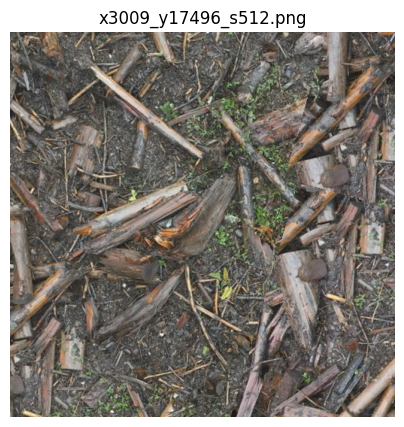

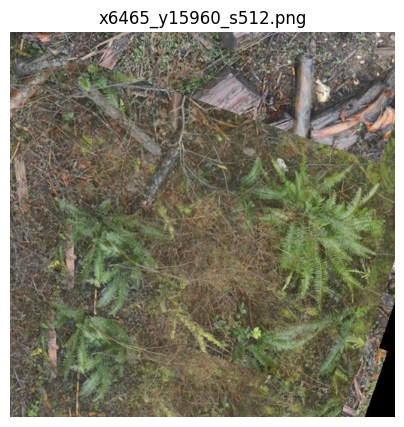

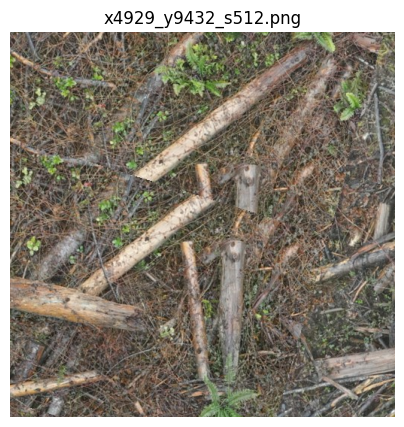

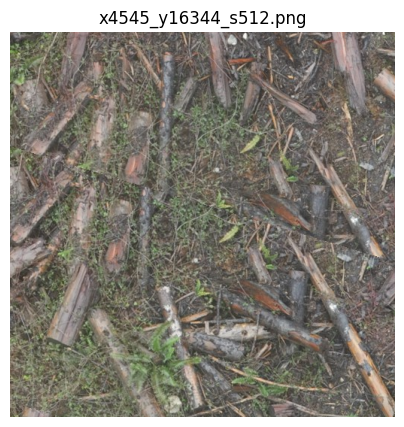

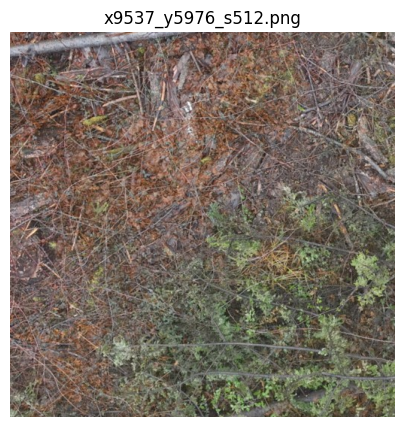

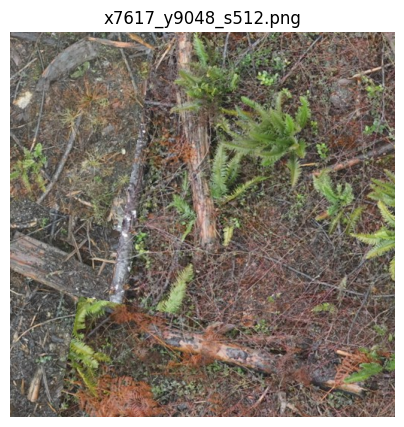

In [7]:
# 6 (optional) — Preview a few saved tiles

import random
from PIL import Image

tiles = list((OUT_DIR / "images").glob("*.png"))

print("Number of tiles:", len(tiles))

if plt is None:
    print("matplotlib not available; skipping preview.")

elif not tiles:
    print("No tiles saved.")

else:
    sample = random.sample(tiles, k=min(6, len(tiles)))

    for p in sample:
        img = np.array(Image.open(p))

        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis("off")
        plt.show()